# Introduction

This notebook aims to analyse and present data from a Set of Experiments. The goal of this experiments is to highlight the influence of various factors on the quality of photogrammetric 3D reconstruction. There are 4 factors each with 2 levels. The factors in this case were as follows:

    1. Capture Pattern: Circular vs Spiral
    2. Working Distance(WD): Near(1.5R) vs  Far(2R)
    3. Number of Photos(Photos #): 48 vs 72
    4. Tilt: 1(tilted) or 0(no tilt)
   
Images were taken with the above parameters and evaluated in Meshroom 2023.2.0. Within Meshroom, 3 feature extractor presets were considered: SIFT, DSIFT and DSIFT+SIFT. The results are captured in the spreadsheet on the sheet labeled "Exp3". A flattened version of the same sheet(Exp3) is on the sheet labelled("Exp3_Flatenned"). The main reason for choosing multiple options for feature extractors was to determine which one is least inconsistent when it comes to Estimating Camera Extrinsics(poses). From the data there is the column: OFfViews that shows the number of estimated camera posisions that were "misplaced".

# 1. Load all Experiment Data

Is the default feature extractor in Meshroom 2023.2.0.
Each set of images was reconstructed 3 times using three different extractor settings. These are the SIFT, DSP-SIFT and DSP-SIFT+SIFT.

Load all the data in and group them by their respective Extractors.

In [1]:
# Load the necessary python modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal

Cols = ["Pattern", "WD", "Photos", "Tilt", "OffViews","Extractor","RMS"]

# Load DSIFT data
all_datadf = pd.read_excel('PreliminaryExperimentResults.xlsx', sheet_name='Exp3_Flattened', header=0, usecols=Cols )

dsift_df = all_datadf[all_datadf["Extractor"]=="DSIFT" ]
sift_df = all_datadf[all_datadf["Extractor"]=="SIFT" ]
sift_dsift_df = all_datadf[all_datadf["Extractor"]=="SIFT_DSIFT" ]

# Analysis of the Data based on Extractors

During Reconstruction, feature extration is the step in the reconstruction pipeline that extracts distinctive groups of pixels that are to a significant extent invariant to the different viewpoints during image acquisition. For these set of experiments, there are 3 extractor choice considered. These are: 1. SIFT 2. DSPSIFT 3. SIFT + DSPSIFT

The reconstructions from each of the constructors had 2 results that were up for consideration, these are the RMS and the Offset Views. The Offsets refer to the view points after the SfM step in Meshroom that were clearly out of place. The RMSE metric quantifies the difference between the reconstruction and the ground truth.

In [2]:
#Description of the Data So far
display(dsift_df.describe())
display(sift_df.describe())
display(sift_dsift_df.describe())

,WD,Photos,Tilt,OffViews,RMS
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,1.750000,60.000000,0.500000,1.375000,0.295852
std,0.258199,12.393547,0.516398,2.753785,0.239802
min,1.500000,48.000000,0.000000,0.000000,0.037927
25%,1.500000,48.000000,0.000000,0.000000,0.116265
50%,1.750000,60.000000,0.500000,0.000000,0.197003
75%,2.000000,72.000000,1.000000,1.250000,0.391446
max,2.000000,72.000000,1.000000,9.000000,0.768339


,WD,Photos,Tilt,OffViews,RMS
count,16.000000,16.000000,16.000000,16.0000,16.000000
mean,1.750000,60.000000,0.500000,0.5625,0.267233
std,0.258199,12.393547,0.516398,2.2500,0.200537
min,1.500000,48.000000,0.000000,0.0000,0.036991
25%,1.500000,48.000000,0.000000,0.0000,0.094318
50%,1.750000,60.000000,0.500000,0.0000,0.274352
75%,2.000000,72.000000,1.000000,0.0000,0.327829
max,2.000000,72.000000,1.000000,9.0000,0.687837


,WD,Photos,Tilt,OffViews,RMS
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,1.750000,60.000000,0.500000,1.312500,0.250606
std,0.258199,12.393547,0.516398,2.301268,0.221758
min,1.500000,48.000000,0.000000,0.000000,0.035867
25%,1.500000,48.000000,0.000000,0.000000,0.117066
50%,1.750000,60.000000,0.500000,0.000000,0.153525
75%,2.000000,72.000000,1.000000,1.250000,0.298758
max,2.000000,72.000000,1.000000,7.000000,0.720302


## Statistical Testing: Parametric vs Non-Parametric

Parametric tests assume specific distributions and relationships in data (e.g., normality, linearity) and include t-tests, ANOVA, and linear regression. They're powerful but sensitive to assumptions.

Non-parametric tests make fewer assumptions about data distribution and types, making them robust for various situations. Examples include Mann-Whitney U, Kruskal-Wallis tests, and Spearman's rank correlation. They're suitable when data violate parametric assumptions or are non-standard.

Choosing between them depends on data characteristics and assumptions being met. If data meet parametric assumptions, those tests are preferred for their higher power. Otherwise, non-parametric tests are more suitable.

## Check the Normality and Homogeniety of of the Data and its variance respectively

A number of statistical tests assume that the data is normally distributed. There are tools that allow one to confirm if the data is indeed normally distributed. One such tool is the [**Shapiro-Wilk Test**](https://www.spss-tutorials.com/spss-shapiro-wilk-test-for-normality/). In simple(but not technically correct) terms, the Shapiro-Wilk Test quantifies the similarity between the observed data and a normals distribution by superimposing a normal distribution over the data and computing the overlap as a percentage. ![Sample Image](https://spss-tutorials.com/img/shapiro-wilk-test-what-is-it.png)

Another common assumption for statistical tests, is the homogeneity of variances(also known as homoscedasticity). This is espeically critical when the sample sizes are largely different. Levene's and Bartlett's test can be used to affirm this. The former is less sensitive to departures from Normality.

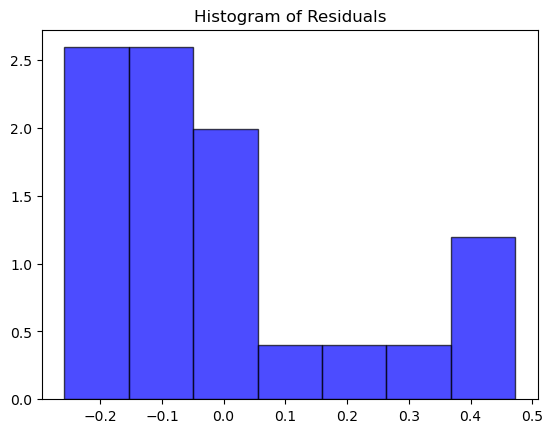

Shapiro-Wilk Test Statistic: 0.8602972030639648, p-value: 4.1282888560090214e-05
Shapiro-Wilk test: Residuals do not appear to be normally distributed.


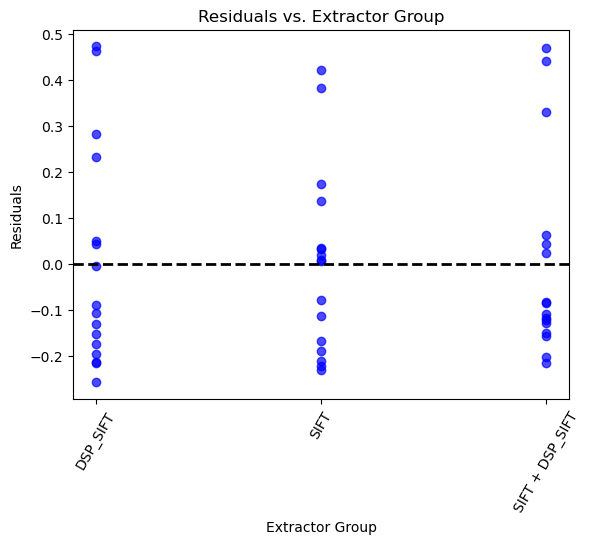

Levene's Test Statistic: 0.17563514175648165, p-value: 0.8394963218285071
Levene's test: Variances appear to be homogeneous.


In [13]:
# Get modules for Shapiro-Wilkins and Levene's Test
from scipy.stats import shapiro, levene

# Organise/Group Data for Tests
RMSs = [
    list(dsift_df["RMS"]),
    list(sift_df["RMS"]),
    list(sift_dsift_df["RMS"])
]

OffViews = [
    list(dsift_df["OffViews"]),
    list(sift_df["OffViews"]),
    list(sift_dsift_df["OffViews"])
]

extractors = ["DSP-SIFT", "SIFT", "SIFT & DSP-SIFT"]
residuals = dict()

# Calculate Residuals then concatenate them all
for i in range(len(RMSs)):
    if i == 0:
        residuals["DSIFT"] = []
        for obs in RMSs[i]:
            residuals["DSIFT"].append( obs - np.mean(RMSs[i]) )
    if i == 1:
        residuals["SIFT"] = []
        for obs in RMSs[i]:
            residuals["SIFT"].append( obs - np.mean(RMSs[i]) )
    if i == 2:
        residuals["SIFT_DSIFT"] = []
        for obs in RMSs[i]:
            residuals["SIFT_DSIFT"].append( obs - np.mean(RMSs[i]))
all_residuals = np.concatenate( [residuals["DSIFT"], residuals["SIFT"], residuals["SIFT_DSIFT"]  ])

# Visual inspection for normality
plt.figure()
plt.hist(all_residuals, bins='auto', density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Residuals')
plt.show()

# Statistical test for normality (Shapiro-Wilk)
stat, p_value = shapiro(all_residuals)
print(f'Shapiro-Wilk Test Statistic: {stat}, p-value: {p_value}')

if p_value > 0.05:
    print("Shapiro-Wilk test: Residuals appear to be normally distributed.")
else:
    print("Shapiro-Wilk test: Residuals do not appear to be normally distributed.")


# Visual inspection for homogeneity of variances
plt.figure()
plt.scatter(np.repeat([1, 2, 3], 16), all_residuals, alpha=0.7, color='blue')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Extractor Group')
plt.ylabel('Residuals')
plt.title('Residuals vs. Extractor Group')
plt.xticks([1,2,3],['DSP_SIFT', 'SIFT', 'SIFT + DSP_SIFT'],rotation=60)
plt.show()


# Statistical test for homogeneity of variances (Levene's test)
stat, p_value = levene(*RMSs)
print(f'Levene\'s Test Statistic: {stat}, p-value: {p_value}')
# Interpret the results
if p_value > 0.05:
    print("Levene's test: Variances appear to be homogeneous.")
else:
    print("Levene's test: Variances do not appear to be homogeneous.")


## Analysis of the Extractors

Since the data does not conform to the assumptions for paramatric analysis. Non-parametric tests are worth considering for the data at hand. Kruskals-Wallis and Friedman's Test are 2 tests that are analogous to ANOVA. 

**Kruskal-Wallis Test:** Compares different groups to see if their medians are different. Works for independent groups with one variable. Useful when normality assumptions are violated in one-way ANOVA.

**Friedman's Test:** Compares multiple measures on the same subjects to see if their medians differ.
Works for related samples with multiple variables. Suitable for within-subject designs or repeated measures when assumptions for ANOVA are violated.
**Key Differences:**
 
     - Kruskal-Wallis: Compares independent groups.
     - Friedman's: Compares related or matched samples (within-subject designs).
     - Kruskal-Wallis compares groups, while Friedman's compares multiple measures within the same subjects.
     
Since I only have 2 levels, for each factor, using the non-parametric tests may be pointless as I will only be having 2 groups of data. However, testing for interactions may be a better way of utilising both tests as I will now be having 4 groups of data.

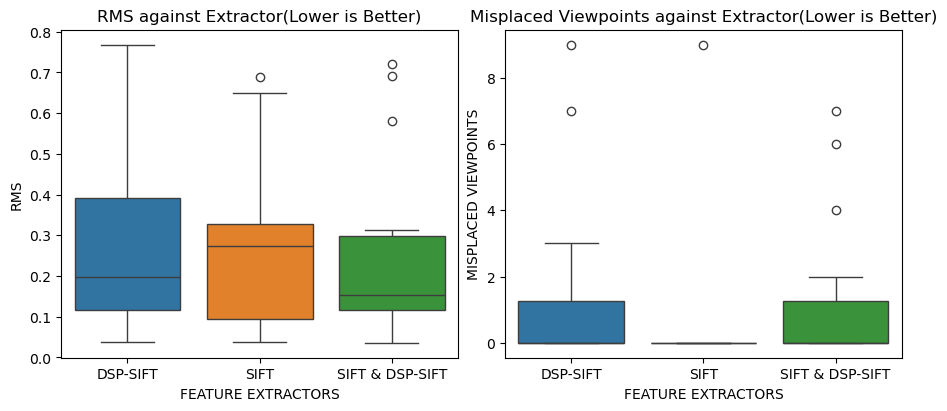

P value for the ANOVA result of the RMS factor across the Extractors: 0.838333500498802 


In [19]:
fig, axs = plt.subplots(1,2, figsize =(9,4), layout="constrained")

sns.boxplot(data=RMSs, ax=axs[0])

sns.boxplot(data=OffViews, ax=axs[1])

for ax,title, y_label in list( zip( axs, 
                          ["RMS against Extractor(Lower is Better)", "Misplaced Viewpoints against Extractor(Lower is Better)"], 
                          ["RMS", "MISPLACED VIEWPOINTS"] ) ):
    ax.set_title(title)
    ax.set_xticks( range(len(extractors)), extractors )
    ax.set_ylabel(y_label)
    ax.set_xlabel("FEATURE EXTRACTORS")

plt.show()

import scipy.stats as stats
# Perform the ANOVA
kruskal_extractors = kruskal( *RMSs )

print(f"P value for the ANOVA result of the RMS factor across the Extractors: {kruskal_extractors.pvalue} ")

# Analysis of Factors

## Interaction Between Pattern and Distance

In [246]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test for Factor A
kruskal_result_A = kruskal( 
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Spiral") & (sift_dsift_df["WD"]==1.5) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Circular") & (sift_dsift_df["WD"]==1.5) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Spiral") & (sift_dsift_df["WD"]==2) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Circular") & (sift_dsift_df["WD"]==2) ]["RMS"],
)

# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic:", kruskal_result_A.statistic)
print("P-value (Factor A):", kruskal_result_A.pvalue)

Kruskal-Wallis Test Statistic (Factor A): 2.933823529411768
P-value (Factor A): 0.4019412273495354


## Interaction Between Pattern and Tilt

In [248]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test for Factor A
kruskal_result_A = kruskal( 
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Spiral") & (sift_dsift_df["Tilt"]==0) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Circular") & (sift_dsift_df["Tilt"]==0) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Spiral") & (sift_dsift_df["Tilt"]==1) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Circular") & (sift_dsift_df["Tilt"]==1) ]["RMS"],
)

# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic (Factor A):", kruskal_result_A.statistic)
print("P-value (Factor A):", kruskal_result_A.pvalue)

Kruskal-Wallis Test Statistic (Factor A): 2.338235294117652
P-value (Factor A): 0.5052356382967493


## Interaction Between Pattern and Num of Photos

In [250]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test for Factor A
kruskal_result_A = kruskal( 
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Spiral") & (sift_dsift_df["Photos"]==48) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Circular") & (sift_dsift_df["Photos"]==48) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Spiral") & (sift_dsift_df["Photos"]==72) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Pattern"]=="Circular") & (sift_dsift_df["Photos"]==72) ]["RMS"],
)

# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic (Factor A):", kruskal_result_A.statistic)
print("P-value (Factor A):", kruskal_result_A.pvalue)

Kruskal-Wallis Test Statistic (Factor A): 1.147058823529413
P-value (Factor A): 0.7657277306734471


## Interaction Between Distance and Tilt

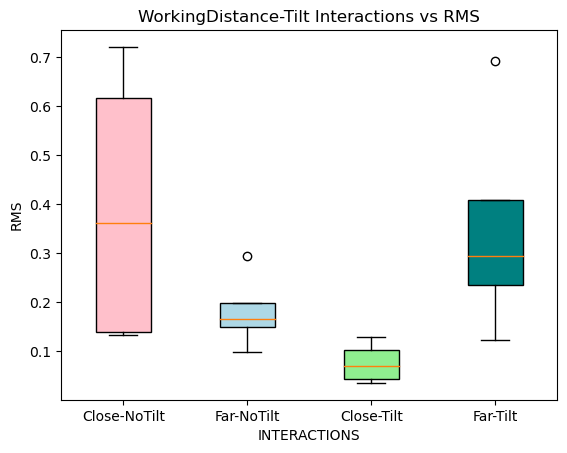

Kruskal-Wallis Test Statistic: 7.786764705882355
P-value : 0.050630459227925424


In [331]:
from scipy.stats import kruskal

WD_Tilt_Labels = [ "Close-NoTilt", "Far-NoTilt", "Close-Tilt", "Far-Tilt", ]
WD_Tilt_RMS = [
    sift_dsift_df[(sift_dsift_df["WD"]==1.5) & (sift_dsift_df["Tilt"]==0) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["WD"]==2) & (sift_dsift_df["Tilt"]==0) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["WD"]==1.5) & (sift_dsift_df["Tilt"]==1) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["WD"]==2) & (sift_dsift_df["Tilt"]==1) ]["RMS"]
]

WD_Tilt_Data = dict(zip(WD_Tilt_Labels, WD_Tilt_RMS))
WD_Tilt_Data

colors = ['pink', 'lightblue', 'lightgreen','Teal']

fig, ax = plt.subplots()
bplot = ax.boxplot(WD_Tilt_RMS, labels=WD_Tilt_Labels, patch_artist=True)
ax.set_ylabel("RMS")
ax.set_xlabel("INTERACTIONS")
ax.set_title("WorkingDistance-Tilt Interactions vs RMS")

colors = ['pink', 'lightblue', 'lightgreen', "teal"]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

# Perform Kruskal-Wallis test for Factor A
kruskal_WD_Tilt = kruskal( *WD_Tilt_RMS )


# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic:", kruskal_WD_Tilt.statistic)
print("P-value :", kruskal_WD_Tilt.pvalue)

## Interaction Between Distance and Num of Photos

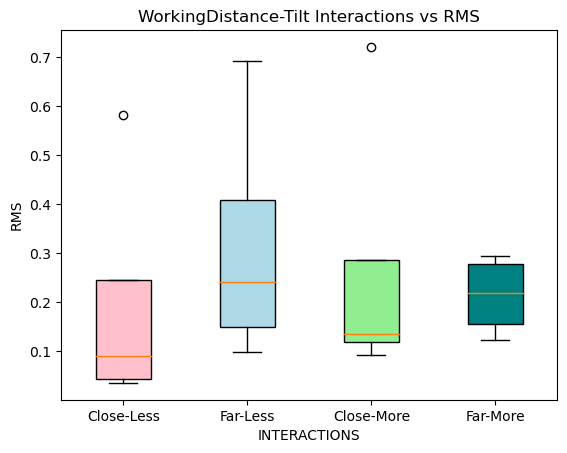

Kruskal-Wallis Test Statistic: 1.919117647058826
P-value: 0.5893626448859981


In [333]:
WD_Photos_Labels = [ "Close-Less", "Far-Less", "Close-More", "Far-More", ]

WD_Photos_RMS = [
    sift_dsift_df[(sift_dsift_df["WD"]==1.5) & (sift_dsift_df["Photos"]==48) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["WD"]==2) & (sift_dsift_df["Photos"]==48) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["WD"]==1.5) & (sift_dsift_df["Photos"]==72) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["WD"]==2) & (sift_dsift_df["Photos"]==72) ]["RMS"]
]

WD_Photos_Data = dict(zip(WD_Photos_Labels, WD_Photos_RMS))


colors = ['pink', 'lightblue', 'lightgreen','Teal']

fig, ax = plt.subplots()
bplot = ax.boxplot(WD_Photos_RMS, labels=WD_Photos_Labels, patch_artist=True)
ax.set_ylabel("RMS")
ax.set_xlabel("INTERACTIONS")
ax.set_title("WorkingDistance-Tilt Interactions vs RMS")

colors = ['pink', 'lightblue', 'lightgreen', "teal"]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

# Perform Kruskal-Wallis test for Factor A
kruskal_WD_Photo = kruskal( *WD_Photos_RMS )

# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic:", kruskal_WD_Photo.statistic)
print("P-value:", kruskal_WD_Photo.pvalue)

## Interaction Between Tilt and Num of Photos

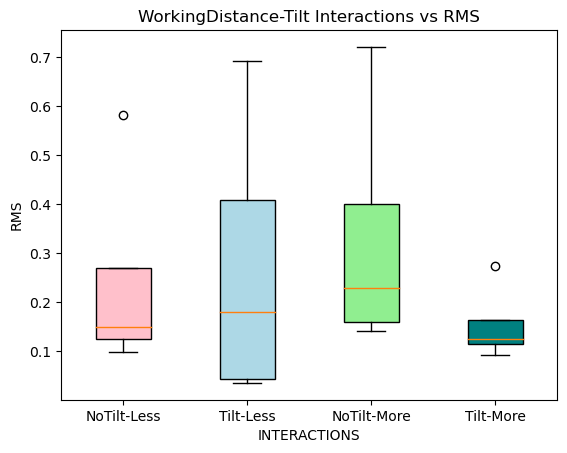

Kruskal-Wallis Test Statistic: 2.338235294117652
P-value: 0.5052356382967493


In [332]:
Tilt_Photos_Labels = [ "NoTilt-Less", "Tilt-Less", "NoTilt-More", "Tilt-More", ]

Tilt_Photos_RMS = [
    sift_dsift_df[(sift_dsift_df["Tilt"]==0) & (sift_dsift_df["Photos"]==48) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Tilt"]==1) & (sift_dsift_df["Photos"]==48) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Tilt"]==0) & (sift_dsift_df["Photos"]==72) ]["RMS"],
    sift_dsift_df[(sift_dsift_df["Tilt"]==1) & (sift_dsift_df["Photos"]==72) ]["RMS"]
]

Tilt_Photos_Data = dict(zip(Tilt_Photos_Labels, Tilt_Photos_RMS))


colors = ['pink', 'lightblue', 'lightgreen','Teal']

fig, ax = plt.subplots()
bplot = ax.boxplot(Tilt_Photos_RMS, labels=Tilt_Photos_Labels, patch_artist=True)
ax.set_ylabel("RMS")
ax.set_xlabel("INTERACTIONS")
ax.set_title("WorkingDistance-Tilt Interactions vs RMS")

colors = ['pink', 'lightblue', 'lightgreen', "teal"]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

# Perform Kruskal-Wallis test for Factor A
kruskal_tilt_photos = kruskal( *Tilt_Photos_RMS )



# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic:", kruskal_tilt_photos.statistic)
print("P-value:", kruskal_tilt_photos.pvalue)

### 1.2.1 Kruska-Wallis Test

In [32]:
# HELPER FUNCTIONS
def plot2_DFs(df1, df2, titles, column=""):
    fig, axes = plt.subplots(1,2, layout="constrained",  figsize=(12,3))
    for i in range(len(axes)):
        axes[i].axis('off')
        if column == "":
            axes[i].table(cellText=df1.values, colLabels=df1.columns, loc='center')
        else:   
            axes[i].table(cellText=df1.drop(column, axis=1).values, colLabels=df1.drop(column, axis=1).columns, loc='center')
        axes[i].set_title(titles[i])
    
    

# Kruskal-Wallis

In [77]:
from scipy.stats import kruskal

# Example data for a single factor (replace with your actual dataset)
factor_A_level_1 = [10, 12, 8, 11]  # Responses for Level 1 of Factor A
factor_A_level_2 = [9, 130, 7, 10]   # Responses for Level 2 of Factor A

# Perform Kruskal-Wallis test for Factor A
kruskal_result_A = kruskal(factor_A_level_1, factor_A_level_2)

# Display Kruskal-Wallis test statistic and p-value for Factor A
print("Kruskal-Wallis Test Statistic (Factor A):", kruskal_result_A.statistic)
print("P-value (Factor A):", kruskal_result_A.pvalue)

Kruskal-Wallis Test Statistic (Factor A): 0.1897590361445783
P-value (Factor A): 0.6631172453203822


In [70]:
from scipy.stats import kruskal

responses = list(sift_dsift_df["RMS"])
kruskal_result = kruskal(*responses)

# Display Kruskal-Wallis test statistic and p-value
print("Kruskal-Wallis Test Statistic:", kruskal_result.statistic)
print("P-value:", kruskal_result.pvalue)

Kruskal-Wallis Test Statistic: 15.0
P-value: 0.4514172112257256


## 2.1 Analysis by Patterns

The patterns are only 2: circular and spiral.

### Spiral Patterns

Extract from the dataframe records of the Circular and Spiral Patterns Respectively. The Pattern is how the camera moves relative to the target object. In both cases the camera moves about the object twice. In the Circular pattern, the 2 cycles about the object are at a 2 fixed elevations respectively. As for the Spiral, the elevation of the Camera is always changing and no 2 images have the same elevation.

The Question: Which Pattern yields better reconstruction results?

Create a box plot from the 2 to show their distribution.

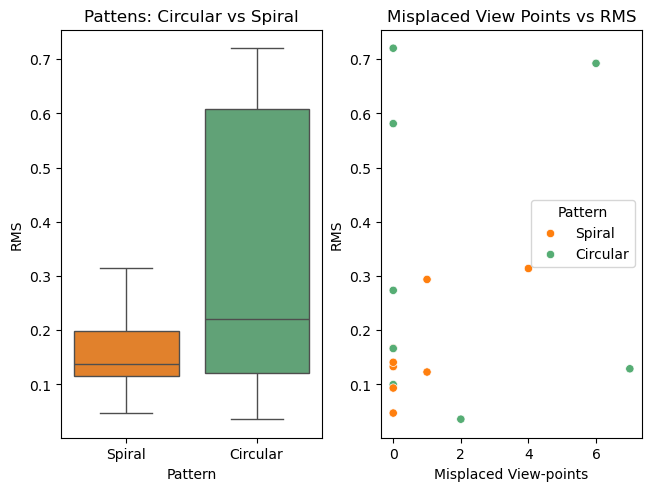

Mann-Whitney U Test Statistic: 24.0. P-value: 0.4418026418026417
Mann-Whitney U Test: The distribution from the 2 groups are equals


In [255]:
# Define custom colors
custom_colors = {'Spiral': '#ff7f0e', 'Circular': '#56ad74'}

fig, axs = plt.subplots(1,2, layout="constrained")
sns.boxplot( data=sift_dsift_df, x="Pattern", y="RMS", hue="Pattern", ax=axs[0], palette=custom_colors)
axs[0].set_title("Pattens: Circular vs Spiral")
axs[0].set_ylabel("RMS")

sns.scatterplot( data=sift_dsift_df, x="OffViews", y="RMS", hue="Pattern", ax=axs[1], palette=custom_colors)
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced View-points")
axs[1].set_title("Misplaced View Points vs RMS")

plt.show()

# Perform Mann-Whitney U test between Factor A, Level 1 and Factor A, Level 2
mannwhitneyu_result = mannwhitneyu(
    list(sift_dsift_df[ sift_dsift_df["Pattern"] == "Spiral" ]["RMS"]), 
    list(sift_dsift_df[ sift_dsift_df["Pattern"] == "Circular" ][ "RMS" ] ), 
    alternative='two-sided'
)

# Display Mann-Whitney U test statistic and p-value
print(f"Mann-Whitney U Test Statistic: {mannwhitneyu_result.statistic}. P-value: {mannwhitneyu_result.pvalue}")

if p_value > 0.05:
    print("Mann-Whitney U Test: The distribution from the 2 groups are equals")
else:
    print("Mann-Whitney U Test: The distribution from the 2 groups are significantlyu different")

## Analysis by Working Distance

Working distance has only 2 levels, 1.5R and 2.0R. R is the radius at which the camera is able to accomodate the longer side of the target object within its horizontal FOV. 1.5R is therefore 1.5 times the radius R while 2.0R is twice the radius R. The 2 distances will be discretised as follows:
    
    - 1.5R => Close
    - 2R => Far

The Question: Which is better being, Far or Close?

/tmp/ipykernel_14159/2519907427.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(labels)


Mann-Whitney U Test Statistic: 21.0. P-value: 0.2786324786324786
Mann-Whitney U Test: The distribution from the 2 groups are equals


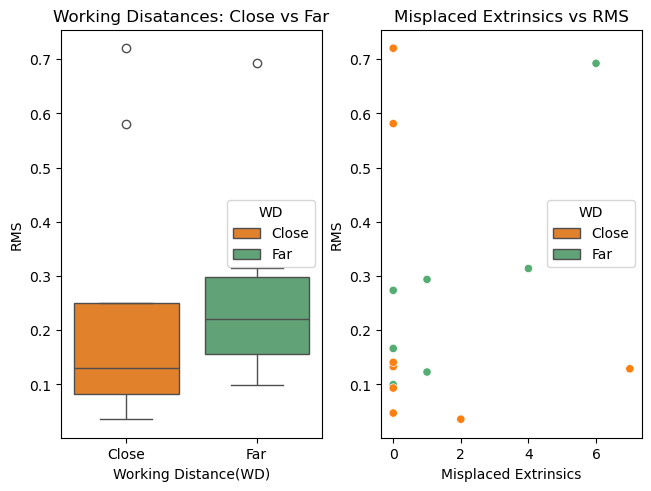

In [256]:
labels = ["Close", "Far"]

# Define custom colors
custom_colors = {1.5: '#ff7f0e', 2.0: '#56ad74'}

fig, axs = plt.subplots(1,2, layout="constrained")
sns.boxplot( data=sift_dsift_df, x="WD", y="RMS", hue="WD", ax=axs[0], palette=custom_colors)
axs[0].set_title("Working Disatances: Close vs Far")
axs[0].set_ylabel("RMS")
axs[0].set_xlabel("Working Distance(WD)")
axs[0].set_xticklabels(labels)
# Rename the Legend Entries
handles, _labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, title='WD')  

sns.scatterplot( data=sift_dsift_df, x="OffViews", y="RMS", hue="WD", ax=axs[1], palette=custom_colors)
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].set_title("Misplaced Extrinsics vs RMS")

# Rename the Legend Entries
handles, _labels = axs[0].get_legend_handles_labels()
axs[1].legend(handles, labels, title='WD')  


# Perform Mann-Whitney U test between Factor A, Level 1 and Factor A, Level 2
mannwhitneyu_result = mannwhitneyu(
    list(sift_dsift_df[ sift_dsift_df["WD"] == 1.5 ]["RMS"]), 
    list(sift_dsift_df[ sift_dsift_df["WD"] == 2 ][ "RMS" ] ), 
    alternative='two-sided'
)

# Display Mann-Whitney U test statistic and p-value
print(f"Mann-Whitney U Test Statistic: {mannwhitneyu_result.statistic}. P-value: {mannwhitneyu_result.pvalue}")

if p_value > 0.05:
    print("Mann-Whitney U Test: The distribution from the 2 groups are equals")
else:
    print("Mann-Whitney U Test: The distribution from the 2 groups are significantlyu different")

## Analysis by number of Photos

The Photos factor had 2 level with the first having 48 photos and the second 72. The choice for each level was arbitrary. The levels can be discretised as Less(48) and More(72).

The Question: Does more photos mean better results?

/tmp/ipykernel_14159/99693999.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(labels)


Mann-Whitney U Test Statistic: 30.0. P-value: 0.8784770784770783
Mann-Whitney U Test: The distribution from the 2 groups are equals


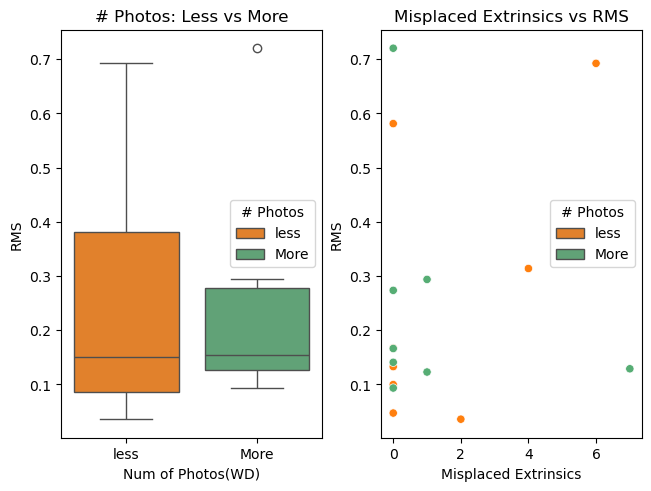

In [257]:
labels = ["less", "More"]

# Define custom colors
custom_colors = {48: '#ff7f0e', 72: '#56ad74'}

fig, axs = plt.subplots(1,2, layout="constrained")
sns.boxplot( data=sift_dsift_df, x="Photos", y="RMS", hue="Photos", ax=axs[0], palette=custom_colors)
axs[0].set_title("# Photos: Less vs More")
axs[0].set_ylabel("RMS")
axs[0].set_xlabel("Num of Photos(WD)")
axs[0].set_xticklabels(labels)

# Rename the Legend Entries
handles, _labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, title='# Photos')  


sns.scatterplot( data=sift_dsift_df, x="OffViews", y="RMS", hue="Photos", ax=axs[1], palette=custom_colors)
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].set_title("Misplaced Extrinsics vs RMS")

# Rename the Legend Entries
handles, _labels = axs[0].get_legend_handles_labels()
axs[1].legend(handles, labels, title='# Photos')  

# Perform Mann-Whitney U test between Factor A, Level 1 and Factor A, Level 2
mannwhitneyu_result = mannwhitneyu(
    list(sift_dsift_df[ sift_dsift_df["Photos"] == 48 ]["RMS"]), 
    list(sift_dsift_df[ sift_dsift_df["Photos"] == 72 ][ "RMS" ] ), 
    alternative='two-sided'
)

# Display Mann-Whitney U test statistic and p-value
print(f"Mann-Whitney U Test Statistic: {mannwhitneyu_result.statistic}. P-value: {mannwhitneyu_result.pvalue}")

if p_value > 0.05:
    print("Mann-Whitney U Test: The distribution from the 2 groups are equals")
else:
    print("Mann-Whitney U Test: The distribution from the 2 groups are significantlyu different")

## Analysis by Tilt

Tilt is whereby the camera **Looks At** the "Centroid" of the target object regardless of its elevation. In the context of Spatial Mechanics, this can be described as the "Pitch" of the camera. For a cirular pattern, there is only ever 2 pitch angles for the each elevation. As for the Spiral Pattern, there are as many pitch angles as there are elevations.

The Question: Does Tilt affect the Resultant reconstruction?

/tmp/ipykernel_14159/4232234257.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(labels)


Mann-Whitney U Test Statistic: 44.0. P-value: 0.23449883449883446
Mann-Whitney U Test: The distribution from the 2 groups are equals


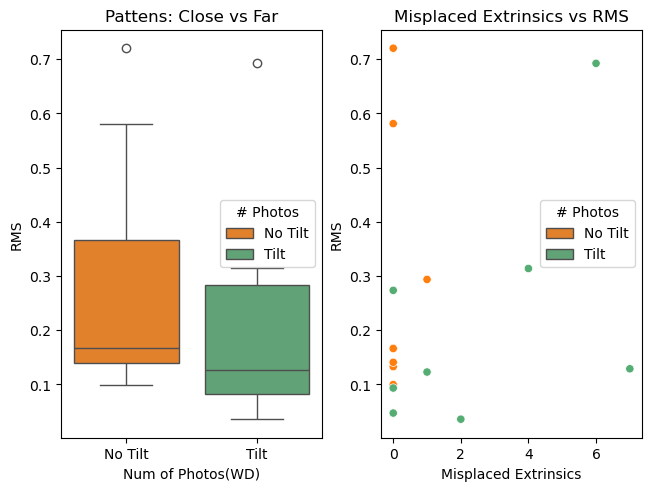

In [258]:
labels = ["No Tilt", "Tilt"]

# Define custom colors
custom_colors = {0: '#ff7f0e', 1: '#56ad74'}

fig, axs = plt.subplots(1,2, layout="constrained")
sns.boxplot( data=sift_dsift_df, x="Tilt", y="RMS", hue="Tilt", ax=axs[0], palette=custom_colors)
axs[0].set_title("Pattens: Close vs Far")
axs[0].set_ylabel("RMS")
axs[0].set_xlabel("Num of Photos(WD)")
axs[0].set_xticklabels(labels)

# Rename the Legend Entries
handles, _labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, title='# Photos')  


sns.scatterplot( data=sift_dsift_df, x="OffViews", y="RMS", hue="Tilt", ax=axs[1], palette=custom_colors)
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].set_title("Misplaced Extrinsics vs RMS")

# Rename the Legend Entries
handles, _labels = axs[0].get_legend_handles_labels()
axs[1].legend(handles, labels, title='# Photos')  

# Perform Mann-Whitney U test between Factor A, Level 1 and Factor A, Level 2
mannwhitneyu_result = mannwhitneyu(
    list(sift_dsift_df[ sift_dsift_df["Tilt"] == 0 ]["RMS"]), 
    list(sift_dsift_df[ sift_dsift_df["Tilt"] == 1 ][ "RMS" ] ), 
    alternative='two-sided'
)

# Display Mann-Whitney U test statistic and p-value
print(f"Mann-Whitney U Test Statistic: {mannwhitneyu_result.statistic}. P-value: {mannwhitneyu_result.pvalue}")

if p_value > 0.05:
    print("Mann-Whitney U Test: The distribution from the 2 groups are equals")
else:
    print("Mann-Whitney U Test: The distribution from the 2 groups are significantlyu different")